# QuSpin Kitaev chain defect operators

Created: 03-06-2026

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spinless_fermion_basis_1d
import numpy as np

In [2]:
import quimb.tensor as qtn
import quimb as qu

In [3]:
import numpy as  np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from tqdm import tqdm

In [67]:
import pickle

# Analysis

## Find grounstates

In [6]:
# Use periodic boundary conditions.
def get_kitaev_chain_hamiltonian(t, L=10):
    static = [
        ["+-", [[-t, i, (i+1)%L] for i in range(L)]],
        ["+-", [[-t, (i+1)%L, i] for i in range(L)]],
        ["--", [[t, i, (i+1)%L] for i in range(L)]],
        ["++", [[t, (i+1)%L, i] for i in range(L)]],
        ["I", [[(1-t)*(0.5), i] for i in range(L)]],
        ["+-", [[-(1-t), i, i] for i in range(L)]]
    ]
    dynamic = []

    basis = spinless_fermion_basis_1d(L, Nf=None)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [7]:
parameters = np.linspace(0,1,201)

In [8]:
kc_hamiltoniains = [
    get_kitaev_chain_hamiltonian(t, 16)
    for t in parameters
]

In [9]:
energies = list()
groundstates = list()

for h in tqdm(kc_hamiltoniains):
    e, psi = h.eigsh(k=1, which='SA')
    energies.append(e[0])
    groundstates.append(psi[:, 0])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [02:59<00:00,  1.12it/s]


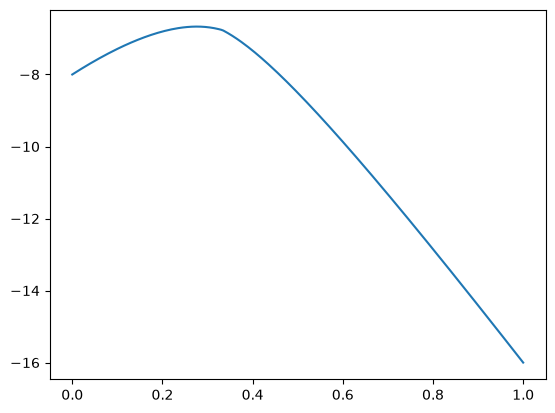

In [10]:
plt.plot(parameters, energies)

In [11]:
energies = np.array(energies)
parameters = np.array(parameters)

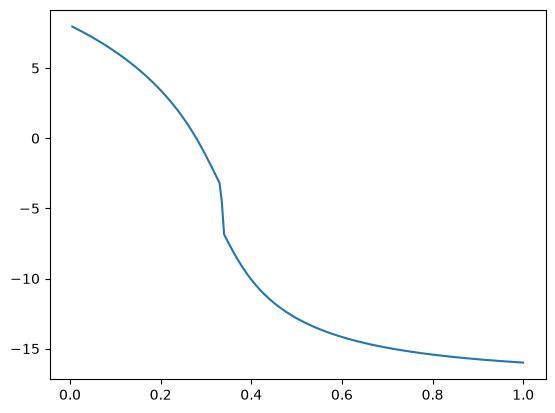

In [12]:
plt.plot(parameters[1:], (energies[1:] - energies[:-1])/(parameters[1]- parameters[0]))

## Expectations and correlation lengths

In [13]:
num_sites = 16
middle_site = num_sites//2

In [14]:
n_middle_site_op = quantum_operator(
    {"n": [["n", [[1, middle_site]]]]},
    basis=spinless_fermion_basis_1d(num_sites, Nf=None),
    dtype=np.complex128
)

Hermiticity check passed!
Symmetry checks passed!


In [15]:
n_middle_site_op.expt_value(groundstates[0])

np.complex128(1.0000000000000002+0j)

In [16]:
n_middle_site_exps = [
    n_middle_site_op.expt_value(psi)
    for psi in groundstates
]

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


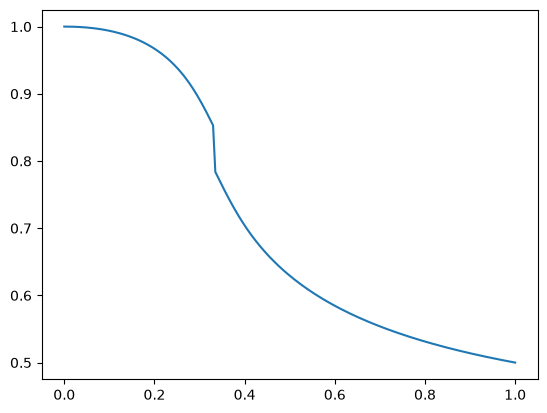

In [17]:
plt.plot(parameters, n_middle_site_exps)

In [18]:
n_site_ops = [
    quantum_operator(
        {"n": [["n", [[1, i]]]]},
        basis=spinless_fermion_basis_1d(num_sites, Nf=None),
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )
    for i in range(num_sites)
]

In [19]:
n_site_exps = [
    [op.expt_value(psi) for psi in groundstates]
    for op in n_site_ops
]

In [20]:
n_site_exps = np.array(n_site_exps)

In [21]:
n_site_exps.shape

(16, 201)

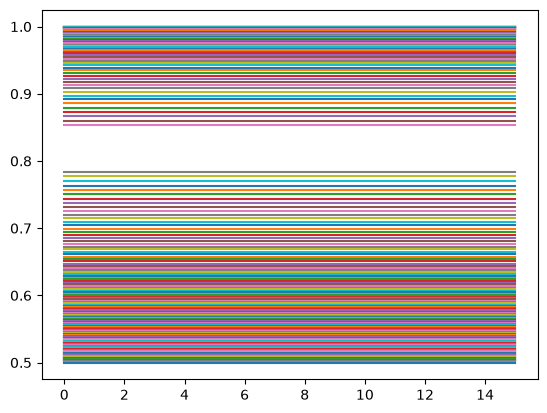

In [22]:
plt.plot(n_site_exps);

In [23]:
n_two_site_ops = [
    quantum_operator(
        {"n": [["nn", [[1, 0, i]]]]},
        basis=spinless_fermion_basis_1d(num_sites, Nf=None),
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )
    for i in range(num_sites//2)
]

In [24]:
n_two_site_exps = [
    [op.expt_value(psi) for psi in groundstates]
    for op in n_two_site_ops
]

n_two_site_exps = np.array(n_two_site_exps)

In [25]:
n_two_site_exps.shape

(8, 201)

In [26]:
n_site_exps.shape

(16, 201)

In [27]:
(n_site_exps[0]*n_site_exps[:(num_sites//2)]).shape

(8, 201)

In [28]:
n_correlations = (
    n_two_site_exps
    -(n_site_exps[0]*n_site_exps[:(num_sites//2)])
)

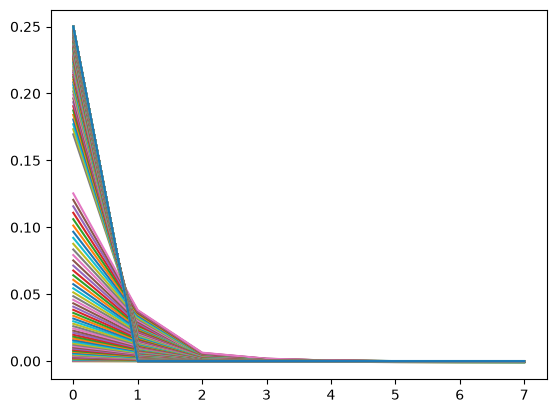

In [29]:
plt.plot(n_correlations);

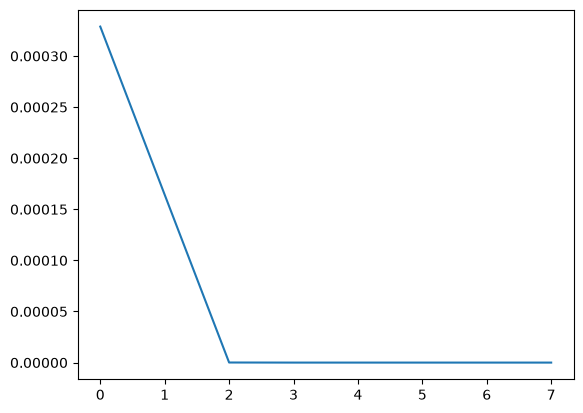

In [30]:
plt.plot(n_correlations[:,5]);

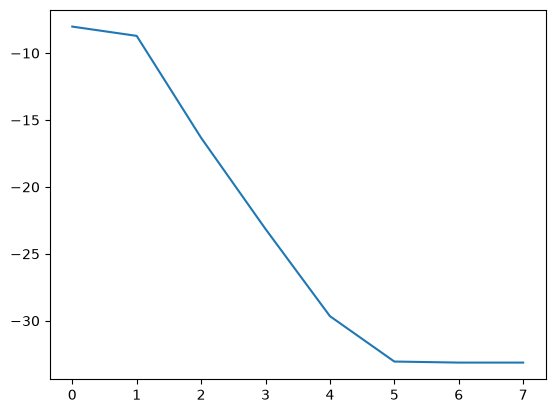

In [31]:
plt.plot(np.log(n_correlations[:,5]))

In [32]:
-6/np.log(n_correlations[5,10]/n_correlations[0,10])

np.complex128(0.2687181124517718-0j)

/tmp/ipykernel_17617/1302409162.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(n_correlations));


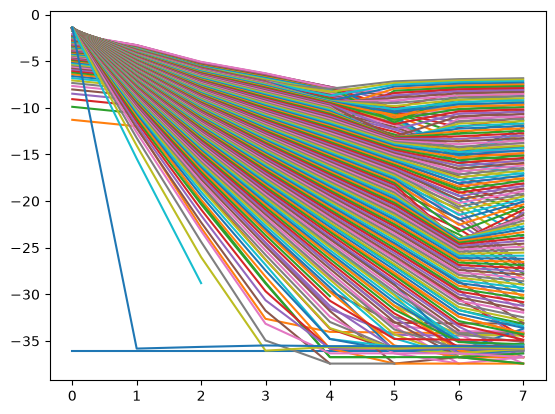

In [33]:
plt.plot(np.log(n_correlations));

In [34]:
n_correlations.shape

(8, 201)

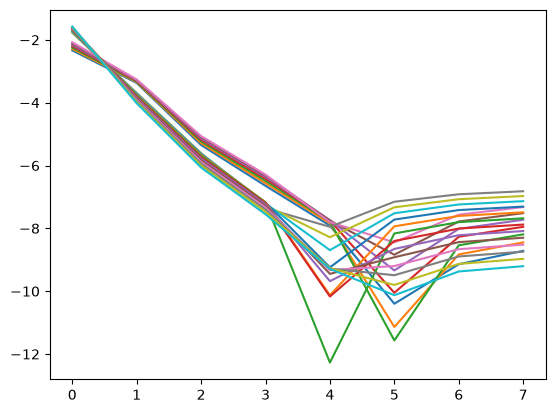

In [35]:
plt.plot(np.log(n_correlations[:, 60:80]));

In [36]:
corr_legnths = -2/np.log(n_correlations[3]/n_correlations[1])

/tmp/ipykernel_17617/2884602841.py:1: RuntimeWarning: divide by zero encountered in log
  corr_legnths = -2/np.log(n_correlations[3]/n_correlations[1])
/tmp/ipykernel_17617/2884602841.py:1: RuntimeWarning: divide by zero encountered in divide
  corr_legnths = -2/np.log(n_correlations[3]/n_correlations[1])
/tmp/ipykernel_17617/2884602841.py:1: RuntimeWarning: invalid value encountered in divide
  corr_legnths = -2/np.log(n_correlations[3]/n_correlations[1])


In [37]:
corr_lengths = np.real(corr_legnths)

In [38]:
corr_lengths = np.nan_to_num(corr_legnths, nan=0)

In [39]:
n_correlations.shape

(8, 201)

In [40]:
np.max(np.abs(np.imag(n_correlations)))

np.float64(0.0)

In [41]:
n_correlations = np.real(n_correlations)

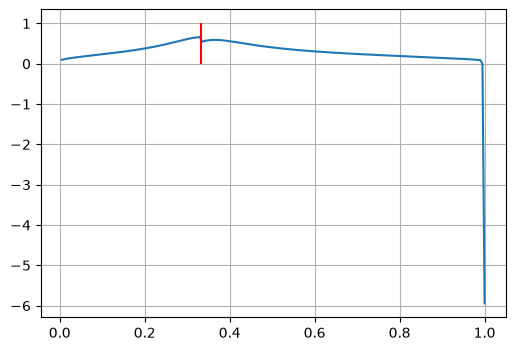

In [42]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(parameters, corr_legnths)
ax.vlines(1/3, ymin=0, ymax=1, color='red')
ax.grid()

## Defect operators

In [43]:
symmetry_sites = list(range(5, 11))
rdm_symmetry_sites = list(range(2, 8))
left_defect_sites = [3,4]
right_defect_sites = [11, 12]
all_defect_sites = left_defect_sites + right_defect_sites

num_symmetry_sites = len(symmetry_sites)
num_defect_sites = len(all_defect_sites)
num_symmetry_and_defect_sites = num_symmetry_sites + num_defect_sites

In [44]:
basis = spinless_fermion_basis_1d(num_sites, Nf=None)
symmetry_and_defect_basis = spinless_fermion_basis_1d(num_symmetry_and_defect_sites, Nf=None)

In [45]:
symmetry_and_defect_basis=spinless_fermion_basis_1d(num_symmetry_and_defect_sites, Nf=None)

rdm_symmetry_sites = list(range(2, 8))

symmetry_op = quantum_operator(
    {"fp": [["z"*len(rdm_symmetry_sites), [[-(2**len(rdm_symmetry_sites)), *rdm_symmetry_sites]]]]},
    basis=symmetry_and_defect_basis,
    dtype=np.complex128
)

defect_basis = spinless_fermion_basis_1d(len(all_defect_sites), Nf=None)

fp_matrix = np.diag([1, -1, -1, 1])

Hermiticity check passed!
Symmetry checks passed!


In [46]:
def get_defect_operator_from_one_sided_environment_matrix(E):
    U, S, Vh = np.linalg.svd(E)
    return ((U @ Vh).conj().T, np.sum(S))

In [47]:
all_defect_sites + symmetry_sites

[3, 4, 11, 12, 5, 6, 7, 8, 9, 10]

In [48]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl1'), edm.ind_size('kl1')),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br2'), edm.ind_size('kr2')),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [49]:
x = qtn.Tensor(data=np.array([[1,2], [3,4]]), inds=['k', 'b'])

In [50]:
x.data

array([[1, 2],
       [3, 4]])

In [51]:
def extract_n1(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=all_defect_sites+symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )

    edm = symmetry_and_defect_basis.partial_trace(
        symmetry_op.matmat(rho),
        sub_sys_A=rdm_symmetry_sites,
        return_rdm='B'
    )
    edm = edm[0]
    
    # Hard code warning.
    # Choice of ind names come from get_defect_operators function.
    reshaped_edm = edm.reshape(4,4,4,4)
    qtn_edm = qtn.Tensor(
        reshaped_edm,
        inds= ['kl1', 'kr2', 'bl1', 'br2']
    )

    (left_defect_op, right_defect_op), scores = get_defect_operators(qtn_edm)

    right_defect_op = (
        right_defect_op
        .transpose('kr2', 'br2')
        .data
    )

    left_defect_op = (
        left_defect_op
        .transpose('kl1', 'bl1')
        .data
    )

    rho_r = basis.partial_trace(
        psi,
        sub_sys_A=right_defect_sites,
        return_rdm="A",
        enforce_pure=True
    )
    
    right_index = np.trace(
        (right_defect_op.T.conj())
        @ fp_matrix
        @ right_defect_op
        @ fp_matrix
        @ rho_r
    )

    rho_l = basis.partial_trace(
        psi,
        sub_sys_A=left_defect_sites,
        return_rdm="A",
        enforce_pure=True
    )
    
    left_index = np.trace(
        (left_defect_op.T.conj())
        @ fp_matrix
        @ left_defect_op
        @ fp_matrix
        @ rho_l
    )
    
    out = [
        left_index,
        right_index,
        scores
    ]

    return out

In [52]:
results = list()

for psi in tqdm(groundstates):
    results.append(extract_n1(psi))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:38<00:00,  5.23it/s]


In [53]:
indices_array = np.array([l[:2] for l in results])

In [56]:
np.max(np.abs(np.imag(indices_array[:, :2])))

np.float64(1.9144649001597387e-16)

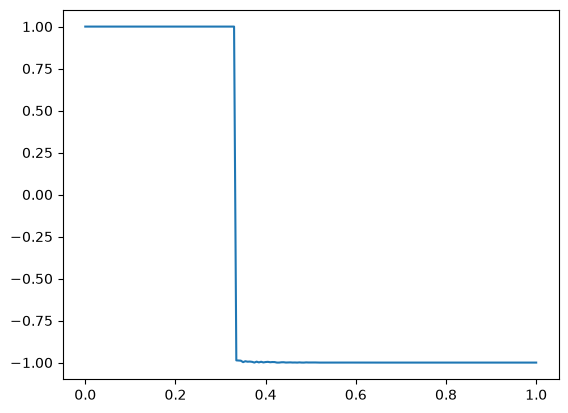

In [58]:
plt.plot(parameters, np.real(indices_array[:, 0]))

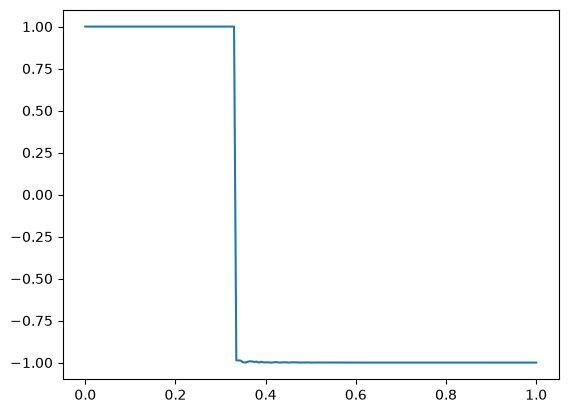

In [59]:
plt.plot(parameters, np.real(indices_array[:, 1]))

In [60]:
scores_array = np.array([l[2][-1] for l in results])

(-0.05, 1.05)

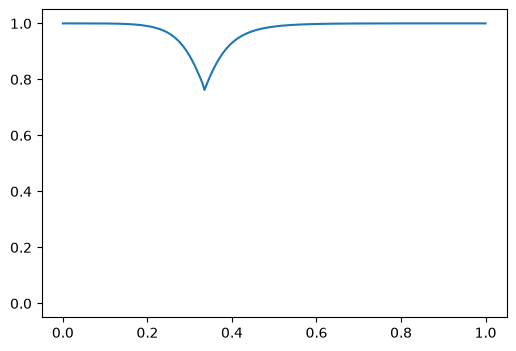

In [61]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(parameters, np.real(scores_array))
ax.set_ylim(-0.05, 1.05)

## Save results

In [82]:
all_results.shape

(201, 4)

In [65]:
all_results = np.concatenate(
    [np.real(indices_array), scores_array[:, np.newaxis]],
    axis=1
)

In [68]:
with open(r'../../make_plots/data/kitaev_chain_defect_operators/results.pkl', 'wb') as f:
    pickle.dump(all_results, f)

# Conclusion
Looks good.